<a href="https://colab.research.google.com/github/Egyy24/FakeNewsDetection/blob/main/FakeNewsDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection using SVM dan Naive Bayes

Project ini mengklasifikasikan artikel berita sebagai FAKE atau REAL menggunakan dua model: Support Vector Machine (SVM) sebagai model utama dan Naive Bayes (MultinomialNB) sebagai baseline pembanding, dengan fitur TF-IDF.

Dataset: ISOT Fake News Dataset (Fake.csv dan True.csv, total 44.898 artikel)

Link Dataset: [ISOT Fake News](https://www.kaggle.com/datasets/rahulogoel/isot-fake-news-dataset)

## Fase 1: Persiapan dan EDA

### Step 1: Import Library yang Dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### Step 2: Data Loading

In [ ]:
fake_df = pd.read_csv('/content/Dataset/Fake.csv', engine='python', on_bad_lines='warn')
true_df = pd.read_csv('/content/Dataset/True.csv', engine='python', on_bad_lines='warn')

# Beri label: 0 = fake, 1 = real
fake_df['label'] = 0
true_df['label'] = 1

# Gabungkan jadi satu dataframe
df = pd.concat([fake_df, true_df], axis=0, ignore_index=True)

# Acak urutan baris (shuffle) supaya fake dan real tercampur, bukan berurutan
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

/tmp/ipykernel_702/3914557982.py:1: ParserWarning: Skipping line 14940: unexpected end of data

  fake_df = pd.read_csv('/content/Dataset/Fake.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_702/3914557982.py:2: ParserWarning: Skipping line 15065: unexpected end of data

  true_df = pd.read_csv('/content/Dataset/True.csv', engine='python', on_bad_lines='warn')


,title,text,subject,date,label
0,Donald Trump Just Got Humiliated By The DICTI...,"On Friday, Donald Trump was so angry about the...",News,"March 4, 2017",0
1,Trump victory may create new tension between U...,JAKARTA (Reuters) - Donald Trump’s U.S. electi...,politicsNews,"November 9, 2016",1
2,UK minister offers parliament new vote on any ...,LONDON (Reuters) - British Brexit minister Dav...,worldnews,"November 13, 2017",1
3,"Senator concerned over U.N., Iran missiles and...",UNITED NATIONS/WASHINGTON (Reuters) - The chai...,politicsNews,"March 30, 2016",1
4,Trump Claims ‘Any Negative Polls’ Are ‘FAKE N...,Donald Trump kicked off his Monday morning by ...,News,"February 6, 2017",0


In [ ]:
df.shape

(30001, 5)

In [ ]:
df['label'].value_counts()

,count
label,
1,15063
0,14938


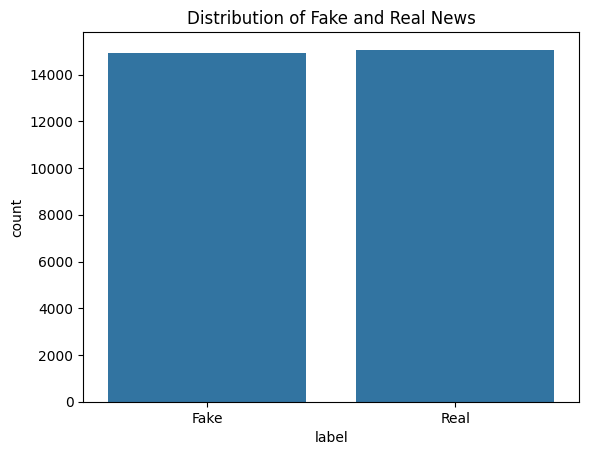

In [ ]:
sns.countplot(data=df, x='label')
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Distribution of Fake and Real News')
plt.show()

Catatan: kolom `subject` tidak dipakai sebagai fitur karena nilainya berbeda antara artikel fake dan real (data leakage). Kita hanya pakai kolom `title` dan `text`.

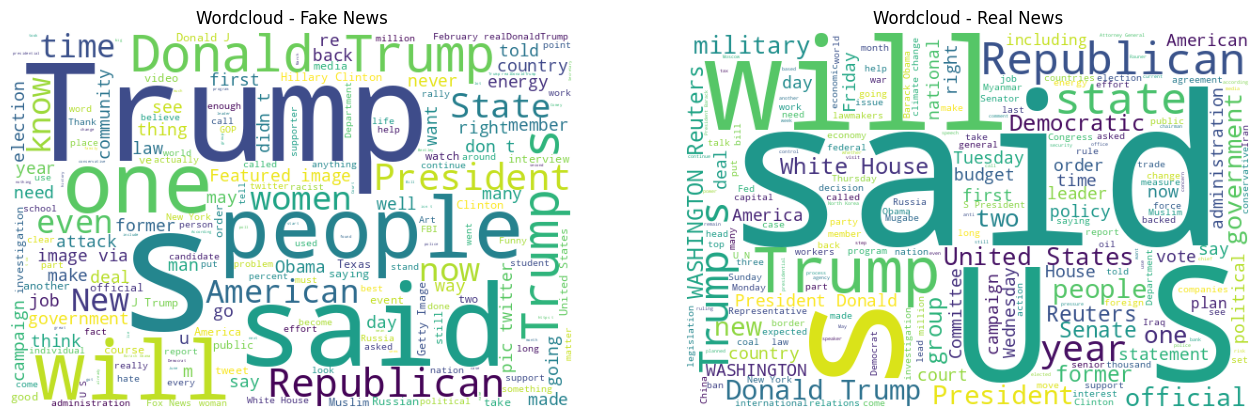

In [ ]:
# Word cloud sederhana untuk melihat kata yang sering muncul di tiap kelas
fake_text = ' '.join(df[df['label'] == 0]['text'].astype(str))
real_text = ' '.join(df[df['label'] == 1]['text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_fake = WordCloud(width=600, height=400, background_color='white').generate(fake_text[:200000])
axes[0].imshow(wc_fake)
axes[0].set_title('Wordcloud - Fake News')
axes[0].axis('off')

wc_real = WordCloud(width=600, height=400, background_color='white').generate(real_text[:200000])
axes[1].imshow(wc_real)
axes[1].set_title('Wordcloud - Real News')
axes[1].axis('off')

plt.show()

## Fase 2: Data Preprocessing

### Step 3: Text Cleaning

In [ ]:
stemmer = PorterStemmer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # hapus URL
    text = re.sub(r'\d+', '', text)               # hapus angka
    text = ''.join([char for char in text if char not in string.punctuation])  # hapus tanda baca

    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Stemming: mereduksi kata ke bentuk dasarnya (e.g. "running" -> "run")
    words = [stemmer.stem(word) for word in words]

    return ' '.join(words)

In [ ]:
# Gabungkan title + text jadi satu kolom, baru dibersihkan
df['content'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df['clean_content'] = df['content'].apply(preprocess_text)

df[['content', 'clean_content']].head()

,content,clean_content
0,Donald Trump Just Got Humiliated By The DICTI...,donald trump got humili dictionari it’ fcking ...
1,Trump victory may create new tension between U...,trump victori may creat new tension us islam i...
2,UK minister offers parliament new vote on any ...,uk minist offer parliament new vote brexit dea...
3,"Senator concerned over U.N., Iran missiles and...",senat concern un iran missil nuclear pact unit...
4,Trump Claims ‘Any Negative Polls’ Are ‘FAKE N...,trump claim ‘ani neg polls’ ‘fake news’ get sa...


## Fase 3: Pemodelan

### Step 4: Feature Extraction (TF-IDF)

In [ ]:
X = df['clean_content']
y = df['label']

vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

print(X_vectorized.shape)

(30001, 5000)


### Step 5: Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (24000, 5000)
Testing shape: (6001, 5000)


### Step 6: Classification using SVM (Model Utama)

In [ ]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test)

pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_svm[:10]
})

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,0,0
4,0,0
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


### Step 7: Classification using Naive Bayes (Baseline)

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test)

pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_nb[:10]
})

,Actual,Predicted
0,1,1
1,1,1
2,1,0
3,0,0
4,0,0
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


## Fase 4: Evaluasi dan Perbandingan

### Step 8: Evaluation - SVM

In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print('SVM Accuracy:', accuracy_svm)
print()
print(classification_report(y_test, y_pred_svm, target_names=['Fake', 'Real']))

SVM Accuracy: 0.9931678053657723

              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      2988
        Real       0.99      1.00      0.99      3013

    accuracy                           0.99      6001
   macro avg       0.99      0.99      0.99      6001
weighted avg       0.99      0.99      0.99      6001



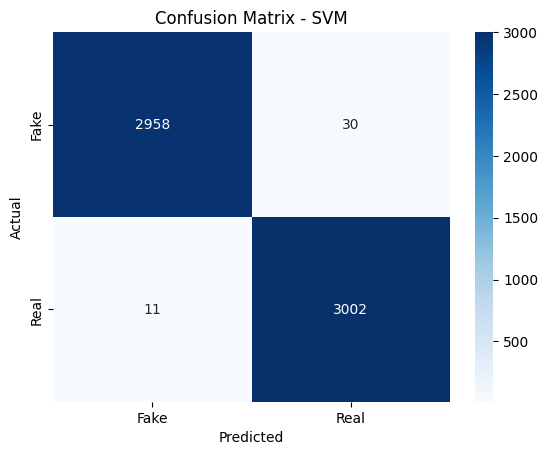

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Step 9: Evaluation - Naive Bayes

In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print('Naive Bayes Accuracy:', accuracy_nb)
print()
print(classification_report(y_test, y_pred_nb, target_names=['Fake', 'Real']))

Naive Bayes Accuracy: 0.9403432761206466

              precision    recall  f1-score   support

        Fake       0.95      0.93      0.94      2988
        Real       0.93      0.95      0.94      3013

    accuracy                           0.94      6001
   macro avg       0.94      0.94      0.94      6001
weighted avg       0.94      0.94      0.94      6001



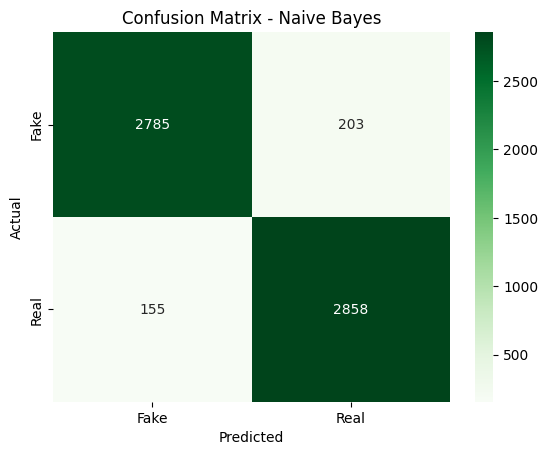

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Step 10: Perbandingan ROC Curve & Ringkasan

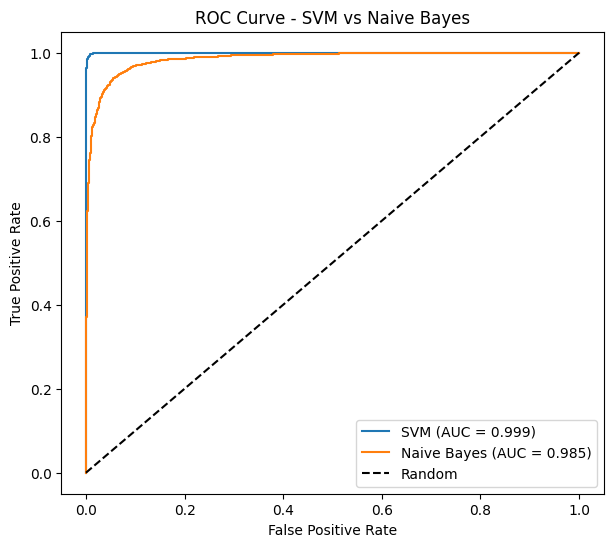

In [ ]:
# SVM (LinearSVC tidak punya predict_proba, pakai decision_function)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_model.decision_function(X_test))
auc_svm = auc(fpr_svm, tpr_svm)

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_model.predict_proba(X_test)[:, 1])
auc_nb = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM vs Naive Bayes')
plt.legend()
plt.show()

In [ ]:
# Tabel ringkasan perbandingan akhir
summary = pd.DataFrame({
    'Model': ['SVM', 'Naive Bayes'],
    'Accuracy': [accuracy_svm, accuracy_nb],
    'AUC': [auc_svm, auc_nb]
})

summary

,Model,Accuracy,AUC
0,SVM,0.993168,0.999378
1,Naive Bayes,0.940343,0.985127


## Fase 5: Finalisasi

### Step 11: Inference (Uji Model dengan Teks Baru)

In [ ]:
new_articles = [
    'Scientists Confirm Earth Is Flat, NASA Admits Cover-Up. Anonymous sources claim this has been hidden for decades.',
    'WASHINGTON (Reuters) - The U.S. Senate on Tuesday passed a bipartisan infrastructure bill after months of negotiations.',
    'You wont believe what this celebrity did, share before its deleted!',
    'The Federal Reserve announced an interest rate decision following its policy meeting on Wednesday.'
]

clean_new_articles = [preprocess_text(article) for article in new_articles]
new_articles_vectorized = vectorizer.transform(clean_new_articles)

predictions = svm_model.predict(new_articles_vectorized)
label_map = {0: 'FAKE', 1: 'REAL'}

for article, prediction in zip(new_articles, predictions):
    print('Article:', article[:80], '...')
    print('Prediction:', label_map[prediction])
    print()

Article: Scientists Confirm Earth Is Flat, NASA Admits Cover-Up. Anonymous sources claim  ...
Prediction: FAKE

Article: WASHINGTON (Reuters) - The U.S. Senate on Tuesday passed a bipartisan infrastruc ...
Prediction: REAL

Article: You wont believe what this celebrity did, share before its deleted! ...
Prediction: FAKE

Article: The Federal Reserve announced an interest rate decision following its policy mee ...
Prediction: FAKE



### Step 12: Simpan Model & Vectorizer (untuk Deploy ke Aplikasi)

In [ ]:
import joblib

# Simpan model SVM (model final, sesuai hasil evaluasi)
joblib.dump(svm_model, 'model.pkl')
print('SVM model saved to model.pkl')

# Simpan TF-IDF Vectorizer
joblib.dump(vectorizer, 'vectorizer.pkl')
print('TF-IDF Vectorizer saved to vectorizer.pkl')

SVM model saved to model.pkl
TF-IDF Vectorizer saved to vectorizer.pkl
